In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import sympy as sp

### Problem 1
Find a solution to the problem
$$\min_x f(x)$$
subject to $x \in \R$ for the function

$$f(x) = -25x+3e^x +33$$

#### Step 1: Solve the equation

In [4]:
# Define symbolic variable
x = sp.symbols('x')

# Defining the function, use sp.exp(x) for e^x
y = -25*x+3*sp.exp(x) + 33 # Fil here the equation of the function

# Derivative and critical points
df = sp.diff(y, x)

# Print the derivative
print("Derivative: ", df)

# Solve for critical points
crit = sp.solve(df, x)

# Print critical points
print(f"Critical points: {crit}")

# Get the optimal value
x_opt = crit[0]
y_opt = y.subs(x, x_opt)

# Print the results of x_opt and y_opt before 
print(f"x_opt: {x_opt}, y_opt: {y_opt}")

# The solution is symbolic, we need to convert it to a float for numerical evaluation
x_opt = float(x_opt)
y_opt = float(y_opt)

print(f"x_opt: {x_opt}, y_opt: {y_opt}")

# Print the results
# print(f"Minimum at x = {x_opt:.2f} with f(x) = {y_opt:.2f}")

Derivative:  3*exp(x) - 25
Critical points: [log(25/3)]
x_opt: log(25/3), y_opt: 58 - 25*log(25/3)
x_opt: 2.120263536200091, y_opt: 4.993411594997724


#### Step 2: Plot the solution

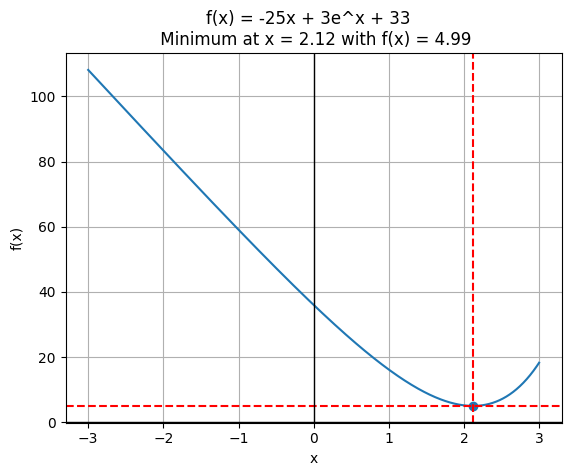

In [6]:
x = np.linspace(-3, 3, 400)
# Use np.exp(x) for e^x
y = -25*x+3*np.exp(x) + 33 # Fill here the equation of the function
      
plt.figure()
plt.plot(x, y)
plt.scatter(x_opt, y_opt)
plt.axvline(x_opt, color='red', linestyle='--')
plt.axhline(y_opt, color='red', linestyle='--')

plt.xlabel("x")                      # X axis label
plt.ylabel("f(x)")                   # Y axis label
plt.axhline(0, linewidth=1, color = 'black')
plt.axvline(0, linewidth=1, color = 'black')

plt.title(f"f(x) = -25x + 3e^x + 33  \n Minimum at x = {x_opt:.2f} with f(x) = {y_opt:.2f}")
plt.grid(True)    
plt.show()

### Problem 2
Minimixze the function $f(x, y, z) = 5x^2+2y^2+3z^2$ subject to the constraint $4x + y + 8z = 9$

#### Step 1: Solve the equation

In [9]:
# Defining the symbols for Lagrange multipliers
x, y, z, lam = sp.symbols('x y z lam')

#Expression for the function and the constraint
f = 5*x**2 + 2*y**2 + 3*z**2
g = 4*x + y + 8*z - 9

# Lagrangian
L = f - lam*g

# Solving the system of equations
eqs = [
    sp.diff(L, x),
    sp.diff(L, y),
    sp.diff(L, z),
    sp.diff(L, lam)
]

#Get the solution
sol = sp.solve(eqs, [x, y, z, lam])
print(f"Solution = {sol}")

Solution = {lam: 540/751, x: 216/751, y: 135/751, z: 720/751}


### Step 2: Verify it is a minimum

In [12]:
# To verify it is a minimum, choose other points that satisfy the constraint 
# from either side of the point we obtained above and calculate at those 
# points. For example, (1, 0, 0) satisfies the constraint.

# Evaluate the function at the solution
x_val = sol[x]
y_val = sol[y]
z_val = sol[z]

f_val = f.subs([(x, x_val), (y, y_val), (z, z_val)])
print(f"Function value at solution: {float(f_val)}")

# Evaluate the function at other points that satisfy the constraint
x_1 = 0
y_1 = 1
z_1 = 1
f_val_1 = f.subs([(x, x_1), (y, y_1), (z, z_1)])
print(f"Validating that the points satisfy the constraint: {4*x_1 + y_1 + 8*z_1 - 9}")
print(f"Function value at (0, 1, 1): {f_val_1}")

# Propose other points that satisfy the constraint values and evaluate 
# the function 
x_2 = 1
y_2 = 1
z_2 = 0.5
f_val_2 = f.subs([(x, x_2), (y, y_2), (z, z_2)])
print(f"Validating that the points satisfy the constraint: {4*x_2 + y_2 + 8*z_2 - 9}")
print(f"Function value at (1, 1, 0.5): {f_val_2}")

Function value at solution: 3.2356857523302263
Validating that the points satisfy the constraint: 0
Function value at (0, 1, 1): 5
Validating that the points satisfy the constraint: 0.0
Function value at (1, 1, 0.5): 7.75000000000000
